In [2]:
# Cell 1: Import Libraries and Set Configuration
"""
Experiment: Analyze how node degree affects Gaussianity of central variable
Spoke-and-wheel topology with non-Gaussian priors on outer variables
"""

import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import sys
sys.path.insert(0, '/home/tom/Projects/gbp_clt/src')
import config as cfg
import distribution_management as dm
import factor_graph as fg
import belief_propagation as bp
from belief_propagation import run_belief_propagation
import optimisation as opt

# Fixed parameters
cfg.belief_discretisation = 1024
cfg.num_iterations = 30
cfg.smoothing_width = 12
cfg.prior_width = 30
cfg.min_measurement = -32
cfg.max_measurement = 31
cfg.measurement_range = np.linspace(cfg.min_measurement, cfg.max_measurement, cfg.belief_discretisation)

# Experiment parameters
num_seeds = 30
min_degree = 2
max_degree = 10
degree_step = 1
degrees = np.arange(min_degree, max_degree + 1, degree_step)
seeds = np.arange(42, 42 + num_seeds)

In [3]:
# Cell 2: Helper Functions

def optimise_gaussian_kl(y_values, x_values):
    """Find Gaussian that minimizes KL divergence from target_belief"""
    bin_width = (x_values[-1] - x_values[0]) / len(x_values)
    sigma_min = 2*bin_width
    sigma_max = (x_values[-1] - x_values[0]) * 10.0
    num_sigma_steps = 100
    
    optimal_mean = x_values[np.argmax(y_values)]
    sigma_search_values = np.logspace(np.log10(sigma_min), np.log10(sigma_max), num_sigma_steps)
    min_kl = float('inf')
    optimal_sigma = None
        
    for sigma_candidate in sigma_search_values:
        y_gauss = opt.create_gaussian_distribution(x_values, sigma_candidate, mu=optimal_mean)
        current_kl = opt.kl_divergence_numba(y_values, y_gauss)

        if np.isnan(current_kl):
            continue

        if current_kl < min_kl:
            min_kl = current_kl
            optimal_sigma = sigma_candidate

    return min_kl, optimal_sigma, optimal_mean

def build_spoke_wheel_graph(num_outer_variables, prior_factor=None):
    """
    Build a spoke-and-wheel graph with:
    - Central variable (index 0) with NO prior
    - num_outer_variables outer variables, each with a non-Gaussian prior
    - Smoothing factors connecting each outer variable to the central variable
    """
    graph = fg.FactorGraph()
    total_variables = num_outer_variables + 1
    graph.add_variables(total_variables, cfg.belief_discretisation)
    
    # Create smoothing function for connections between central and outer variables
    smoothing_kernel = dm.create_random_prior_distribution(
        cfg.measurement_range, 
        prior_width=cfg.smoothing_width
    )
    smoothing_function = dm.create_smoothing_factor_distribution(
        cfg.belief_discretisation, 
        kernel=smoothing_kernel
    )
    
    # Connect each outer variable to central variable (variable 0)
    for i in range(1, total_variables):
        graph.add_factor(
            [graph.variables[0], graph.variables[i]], 
            function=smoothing_function
        )
    
    # Add non-Gaussian priors to all outer variables only
    if prior_factor is None:
        prior_factor = dm.create_random_prior_distribution(
            cfg.measurement_range, 
            prior_width=cfg.prior_width
        )
    
    for i in range(1, total_variables):
        graph.add_factor([graph.variables[i]], prior_factor, factor_type='prior')
    
    return graph


In [4]:
# Cell 3: Run Experiments

print("Running spoke-and-wheel node degree experiments...")
print(f"Using {num_seeds} random seeds")
print(f"Testing degrees from {min_degree} to {max_degree}\n")

# Storage for results: degree -> [kl_values across seeds]
degree_results = defaultdict(list)

for seed_idx, seed in enumerate(seeds):
    print(f"Running seed {seed} ({seed_idx+1}/{num_seeds})...")
    
    # Set random seed
    cfg.random_seed = seed
    cfg.rng = np.random.default_rng(seed=seed)
    np.random.seed(seed)
    
    # Common prior distribution for this seed
    common_prior_distribution = dm.create_random_prior_distribution(
        cfg.measurement_range,
        prior_width=cfg.prior_width
    )
    
    for degree in degrees:
        print(f"  Testing degree {degree}...")
        cfg.measurement_range = np.linspace(cfg.min_measurement, cfg.max_measurement, cfg.belief_discretisation)
        
        # Build spoke-and-wheel graph
        graph = build_spoke_wheel_graph(
            num_outer_variables=degree,
            prior_factor=common_prior_distribution
        )
        
        # Run belief propagation
        graph = bp.run_belief_propagation(graph, cfg.num_iterations)
        
        # Extract central variable's belief and compute KL divergence from Gaussian
        central_variable = graph.variables[0]
        kl_div, optimal_sigma, optimal_mean = optimise_gaussian_kl(
            central_variable.belief, 
            cfg.measurement_range
        )
        
        degree_results[degree].append(kl_div)
    
    print(f"  Seed {seed} complete\n")

print("All experiments complete!")


Running spoke-and-wheel node degree experiments...
Using 30 random seeds
Testing degrees from 2 to 10

Running seed 42 (1/30)...
  Testing degree 2...
Adding variables to graph...
BP Stage 1: Converting graph to numerical representation...
BP Stage 2: Running BP iterations...
BP Stage 3: Updating graph objects with final beliefs...
  Testing degree 3...
Adding variables to graph...
BP Stage 1: Converting graph to numerical representation...
BP Stage 2: Running BP iterations...
BP Stage 3: Updating graph objects with final beliefs...
  Testing degree 4...
Adding variables to graph...
BP Stage 1: Converting graph to numerical representation...
BP Stage 2: Running BP iterations...
BP Stage 3: Updating graph objects with final beliefs...
  Testing degree 5...
Adding variables to graph...
BP Stage 1: Converting graph to numerical representation...
BP Stage 2: Running BP iterations...
BP Stage 3: Updating graph objects with final beliefs...
  Testing degree 6...
Adding variables to graph...


In [5]:
# Cell 4: Compute Statistics

def compute_stats(results_dict):
    degrees = sorted(results_dict.keys())
    means = []
    stds = []
    
    for degree in degrees:
        kl_values = results_dict[degree]
        means.append(np.mean(kl_values))
        stds.append(np.std(kl_values))
    
    return degrees, np.array(means), np.array(stds)

degrees_sorted, kl_means, kl_stds = compute_stats(degree_results)

print("Spoke-and-wheel statistics:")
print(f"  Degrees: {degrees_sorted}")
print(f"  Mean KL: {kl_means}")
print(f"  Std KL: {kl_stds}")


Spoke-and-wheel statistics:
  Degrees: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
  Mean KL: [0.24898034 0.36511621 0.37495389 0.46144761 0.47532584 0.54462562
 0.69059863 0.71373098 0.767961  ]
  Std KL: [0.16001336 0.21050987 0.19024098 0.25130616 0.25461714 0.21207418
 0.32974772 0.33819377 0.32343403]


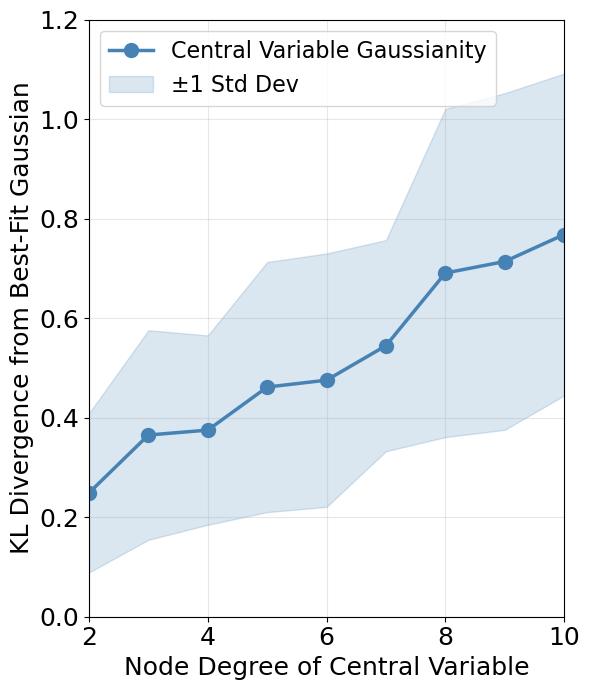

In [9]:
# Cell 5: Plot Results

FIG_SIZE = (6, 7)
AXIS_FONT = 18
TICK_FONT = 18
LEGEND_FONT = 16

fig, ax = plt.subplots(1, 1, figsize=FIG_SIZE)

# Plot KL divergence vs node degree
ax.plot(degrees_sorted, kl_means, 'o-', linewidth=2.5, markersize=10, 
        label='Central Variable Gaussianity', color='steelblue')
ax.fill_between(degrees_sorted, kl_means - kl_stds, kl_means + kl_stds, 
                alpha=0.2, color='steelblue')

# Add a dummy patch for the shaded region legend
from matplotlib.patches import Patch
shaded_patch = Patch(alpha=0.2, color='steelblue', label='±1 Std Dev')

ax.set_xlabel('Node Degree of Central Variable', fontsize=AXIS_FONT)
ax.set_ylabel('KL Divergence from Best-Fit Gaussian', fontsize=AXIS_FONT)
# ax.set_title('Gaussianity of Central Variable vs Node Degree\n(Spoke-and-Wheel Topology)', 
#              fontsize=15, fontweight='bold')
ax.legend(handles=[ax.get_legend_handles_labels()[0][0], shaded_patch], fontsize=LEGEND_FONT, loc='best')
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0, top=1.2)
ax.set_xlim(left=min_degree, right=max_degree)
ax.tick_params(axis='both', labelsize=TICK_FONT)

plt.tight_layout()
plt.savefig('spoke_wheel_node_degree.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()
